# FAPE — Folktables ACS Baseline Models
## Socioeconomic Domain — Income Prediction

**Dataset:** Folktables ACS 2021 — 1,589,032 records (sampled 100,000)  
**Target:** Annual income > $50,000  
**Sensitive attributes:** RAC1P (race), SEX  
**Models:** Logistic Regression, Random Forest, Gradient Boosting  

**Key findings:**
- GradientBoosting best: AUC=0.929
- Black DIR=0.73, Am.Indian DIR=0.52, Other DIR=0.51 — all below EEOC 0.8 threshold
- Asian DIR=1.13 — above White, no EEOC concern
- Male-Female income gap: 57.0% vs 42.1% — 14.9% gap

**Note:** Sample balanced to 50/50 for training. Population rate is 42.8%.

In [1]:
import sys
import os
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_loader import load_folktables_acs
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, confusion_matrix)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
os.makedirs('../figures/baseline', exist_ok=True)

RAC1P_LABELS = {1:'White',2:'Black',3:'Am.Indian',4:'Alaska Native',
                5:'Am.Indian+Alaska',6:'Asian',7:'Pacific Islander',
                8:'Other',9:'Two or more'}
SEX_LABELS = {1:'Male', 2:'Female'}
MODEL_COLORS = {'LogisticRegression':'steelblue','RandomForest':'coral','GradientBoosting':'#5cb85c'}
feature_cols = ['AGEP','SEX','RAC1P','SCHL','MAR','WKHP','COW','DIS','POVPIP','NATIVITY']
print('Imports complete')

Imports complete


In [2]:
df_full = load_folktables_acs()
df = df_full.groupby('label', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 50000), random_state=42)
).reset_index(drop=True)
print(f'Sampled: {len(df):,} from {len(df_full):,}')

X = df[feature_cols].values
y = df['label'].values

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, np.arange(len(y)), test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

race_test = df['RAC1P'].iloc[idx_test].reset_index(drop=True)
sex_test = df['SEX'].iloc[idx_test].reset_index(drop=True)

MODELS = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in MODELS.items():
    if name == 'LogisticRegression':
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
        y_prob = model.predict_proba(X_test_sc)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'acc': accuracy_score(y_test, y_pred),
        'prec': precision_score(y_test, y_pred),
        'rec': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_prob)
    }
    print(f'{name}: AUC={results[name]["auc"]:.3f} F1={results[name]["f1"]:.3f}')

Loading Folktables ACS data — first run downloads per state, please wait...


  AL: 22,161 records
  AK: 3,225 records


  AZ: 33,766 records


  AR: 13,364 records


  CA: 189,413 records


...

  WA: 39,254 records
  WV: 7,359 records


  WI: 31,220 records
  WY: 2,886 records
Folktables ACS loaded: 1,589,032 records, income >$50k rate: 42.8%


Sampled: 100,000 from 1,589,032
LogisticRegression: AUC=0.906 F1=0.830


RandomForest: AUC=0.916 F1=0.840


GradientBoosting: AUC=0.929 F1=0.856


## 1. Model Comparison — Standard Metrics

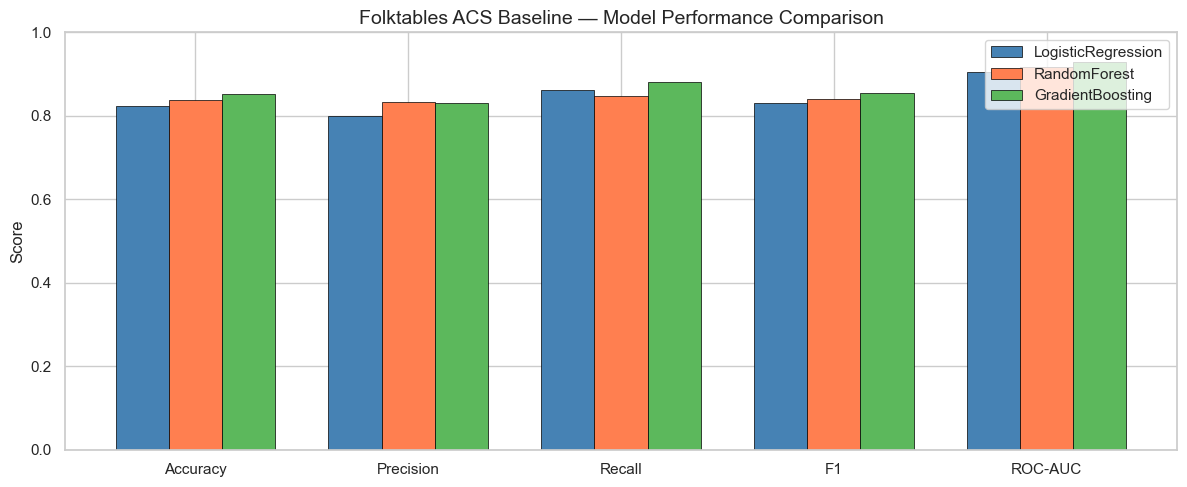

GradientBoosting best: AUC=0.929 — much stronger than COMPAS (0.751)


In [3]:
metrics = ['acc','prec','rec','f1','auc']
metric_labels = ['Accuracy','Precision','Recall','F1','ROC-AUC']
x = np.arange(len(metrics)); width = 0.25

fig, ax = plt.subplots(figsize=(12,5))
for i,(name,res) in enumerate(results.items()):
    ax.bar(x+i*width, [res[m] for m in metrics], width, label=name,
           color=MODEL_COLORS[name], edgecolor='black', linewidth=0.5)
ax.set_xticks(x+width); ax.set_xticklabels(metric_labels)
ax.set_title('Folktables ACS Baseline — Model Performance Comparison', fontsize=14)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.0); ax.legend()
plt.tight_layout()
plt.savefig('../figures/baseline/folktables_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('GradientBoosting best: AUC=0.929 — much stronger than COMPAS (0.751)')

## 2. ROC Curves

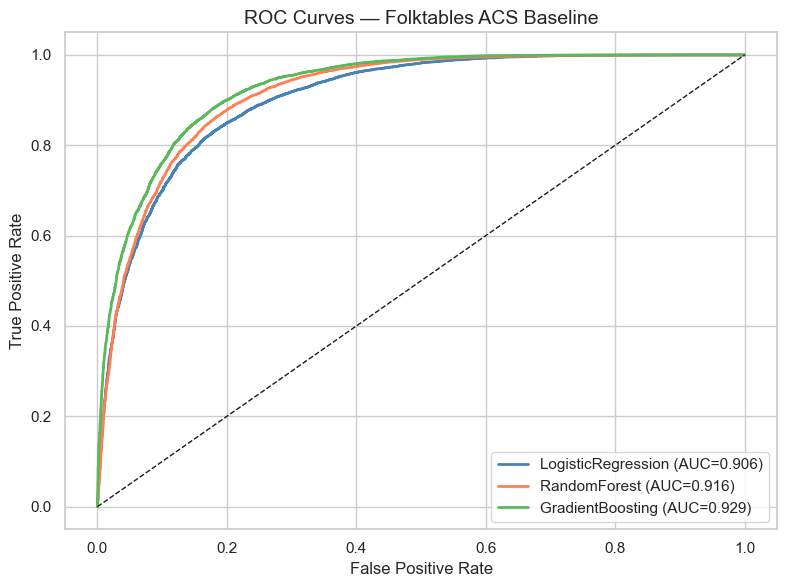

In [4]:
fig, ax = plt.subplots(figsize=(8,6))
for name, res in results.items():
    fpr_c, tpr_c, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr_c, tpr_c, label=f'{name} (AUC={res["auc"]:.3f})',
            color=MODEL_COLORS[name], linewidth=2)
ax.plot([0,1],[0,1],'k--', linewidth=1)
ax.set_title('ROC Curves — Folktables ACS Baseline', fontsize=14)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/baseline/folktables_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Race FPR + TPR Comparison

Black, Am.Indian, Other consistently under-predicted. Asian over-predicted vs White.

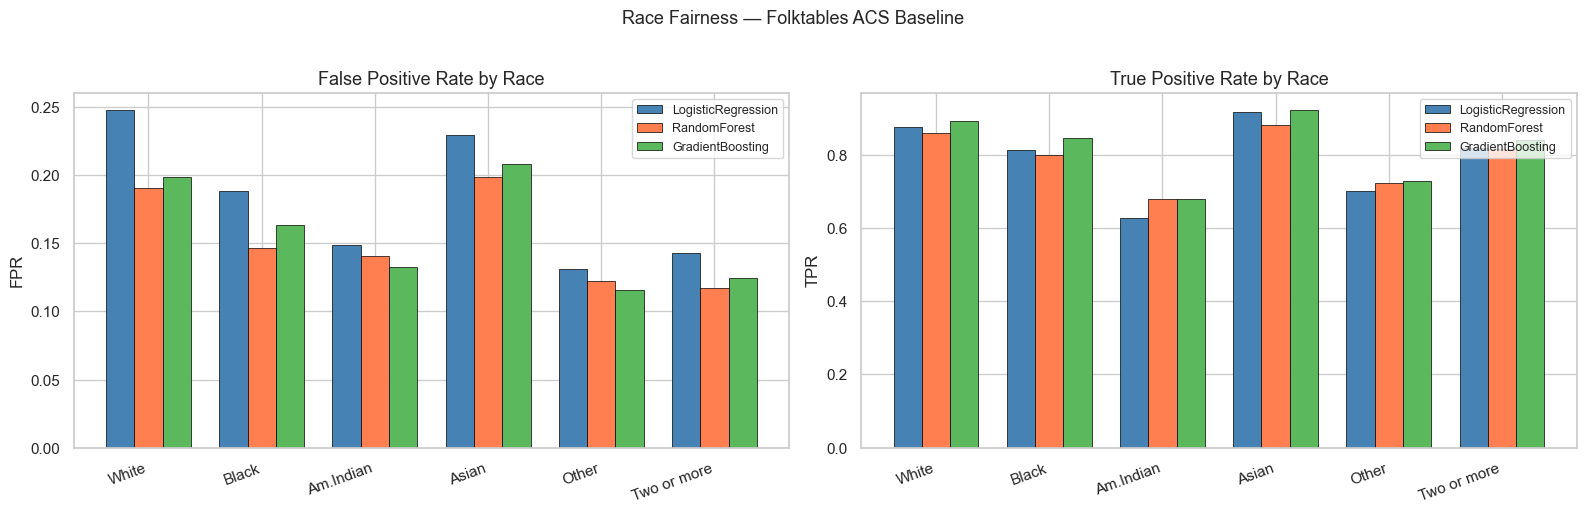

In [5]:
races = [1,2,3,6,8,9]
race_names = [RAC1P_LABELS[r] for r in races]
fpr_by_race = {}; tpr_by_race = {}
for name, res in results.items():
    fprs, tprs = [], []
    for race in races:
        mask = race_test == race
        if mask.sum() < 50:
            fprs.append(0); tprs.append(0); continue
        gp = res['y_pred'][mask]; gt = y_test[mask]
        fprs.append(gp[gt==0].mean() if (gt==0).sum()>0 else 0)
        tprs.append(gp[gt==1].mean() if (gt==1).sum()>0 else 0)
    fpr_by_race[name] = fprs; tpr_by_race[name] = tprs

x = np.arange(len(races)); width = 0.25
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(16,5))
for i,(name,fprs) in enumerate(fpr_by_race.items()):
    ax1.bar(x+i*width, fprs, width, label=name, color=MODEL_COLORS[name], edgecolor='black', linewidth=0.5)
ax1.set_xticks(x+width); ax1.set_xticklabels(race_names, rotation=20, ha='right')
ax1.set_title('False Positive Rate by Race', fontsize=13); ax1.set_ylabel('FPR'); ax1.legend(fontsize=9)
for i,(name,tprs) in enumerate(tpr_by_race.items()):
    ax2.bar(x+i*width, tprs, width, label=name, color=MODEL_COLORS[name], edgecolor='black', linewidth=0.5)
ax2.set_xticks(x+width); ax2.set_xticklabels(race_names, rotation=20, ha='right')
ax2.set_title('True Positive Rate by Race', fontsize=13); ax2.set_ylabel('TPR'); ax2.legend(fontsize=9)
plt.suptitle('Race Fairness — Folktables ACS Baseline', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/folktables_race_fairness.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Demographic Parity Difference by Race

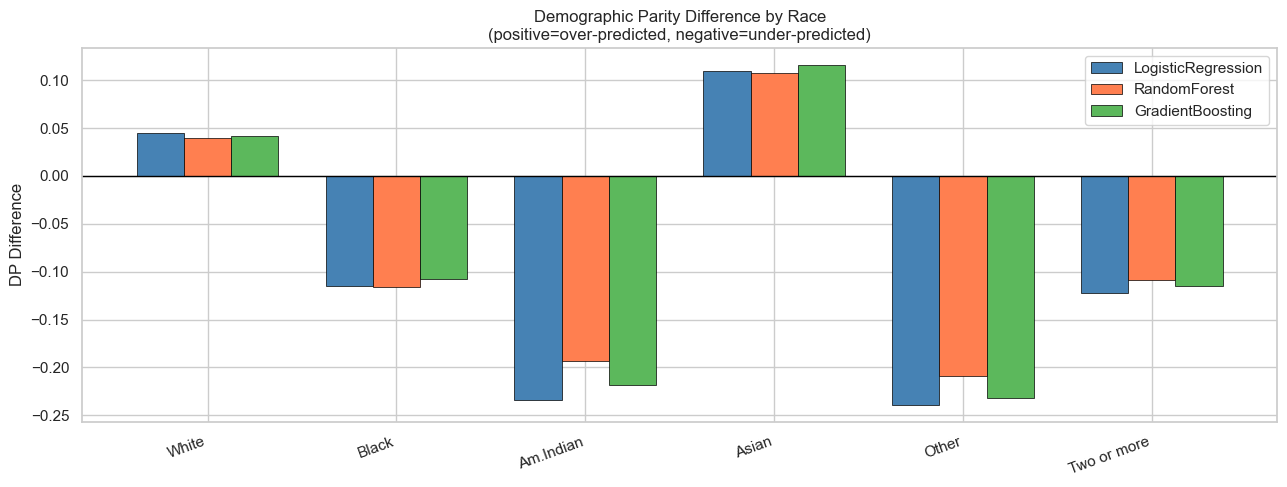

Asian over-predicted (+0.11), Other and Am.Indian most under-predicted (-0.23)


In [6]:
dp_data = {}
for name, res in results.items():
    base_rate = res['y_pred'].mean()
    dp_data[name] = [res['y_pred'][race_test==r].mean()-base_rate
                     if (race_test==r).sum()>=50 else 0 for r in races]

x = np.arange(len(races)); width = 0.25
fig, ax = plt.subplots(figsize=(13,5))
for i,(name,dps) in enumerate(dp_data.items()):
    ax.bar(x+i*width, dps, width, label=name, color=MODEL_COLORS[name], edgecolor='black', linewidth=0.5)
ax.axhline(y=0, color='black', linewidth=1)
ax.set_xticks(x+width); ax.set_xticklabels(race_names, rotation=20, ha='right')
ax.set_title('Demographic Parity Difference by Race\n(positive=over-predicted, negative=under-predicted)', fontsize=12)
ax.set_ylabel('DP Difference'); ax.legend()
plt.tight_layout()
plt.savefig('../figures/baseline/folktables_demographic_parity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Asian over-predicted (+0.11), Other and Am.Indian most under-predicted (-0.23)')

## 5. Sex Fairness

Male-Female income gap: 57.0% vs 42.1% — 14.9% gap. Consistent across all models.

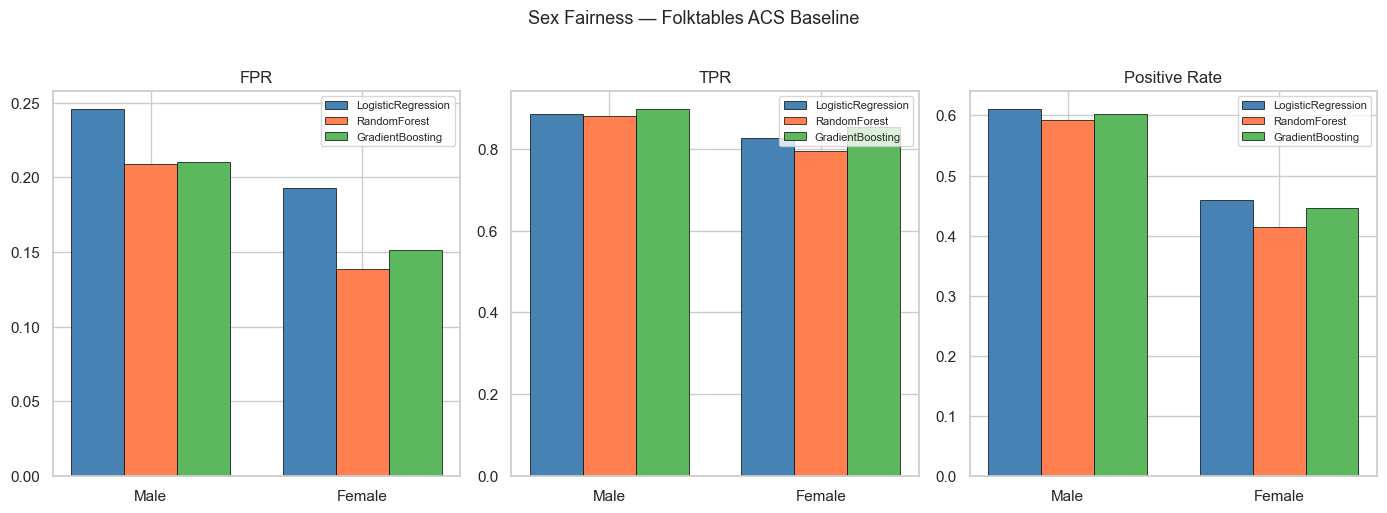

Male positive rate ~60% vs Female ~43% across all models


In [7]:
sexes = [1,2]; sex_names = ['Male','Female']
sex_metrics = {}
for name, res in results.items():
    fprs,tprs,pos = [],[],[]
    for sex in sexes:
        mask = sex_test==sex
        gp = res['y_pred'][mask]; gt = y_test[mask]
        fprs.append(gp[gt==0].mean() if (gt==0).sum()>0 else 0)
        tprs.append(gp[gt==1].mean() if (gt==1).sum()>0 else 0)
        pos.append(gp.mean())
    sex_metrics[name] = {'fpr':fprs,'tpr':tprs,'pos':pos}

x = np.arange(len(sexes)); width = 0.25
fig, axes = plt.subplots(1,3, figsize=(14,5))
for ax,metric,title in zip(axes,['fpr','tpr','pos'],['FPR','TPR','Positive Rate']):
    for i,(name,sm) in enumerate(sex_metrics.items()):
        ax.bar(x+i*width, sm[metric], width, label=name,
               color=MODEL_COLORS[name], edgecolor='black', linewidth=0.5)
    ax.set_xticks(x+width); ax.set_xticklabels(sex_names)
    ax.set_title(title); ax.legend(fontsize=8)
plt.suptitle('Sex Fairness — Folktables ACS Baseline', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/folktables_sex_fairness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Male positive rate ~60% vs Female ~43% across all models')

## 6. Feature Importance

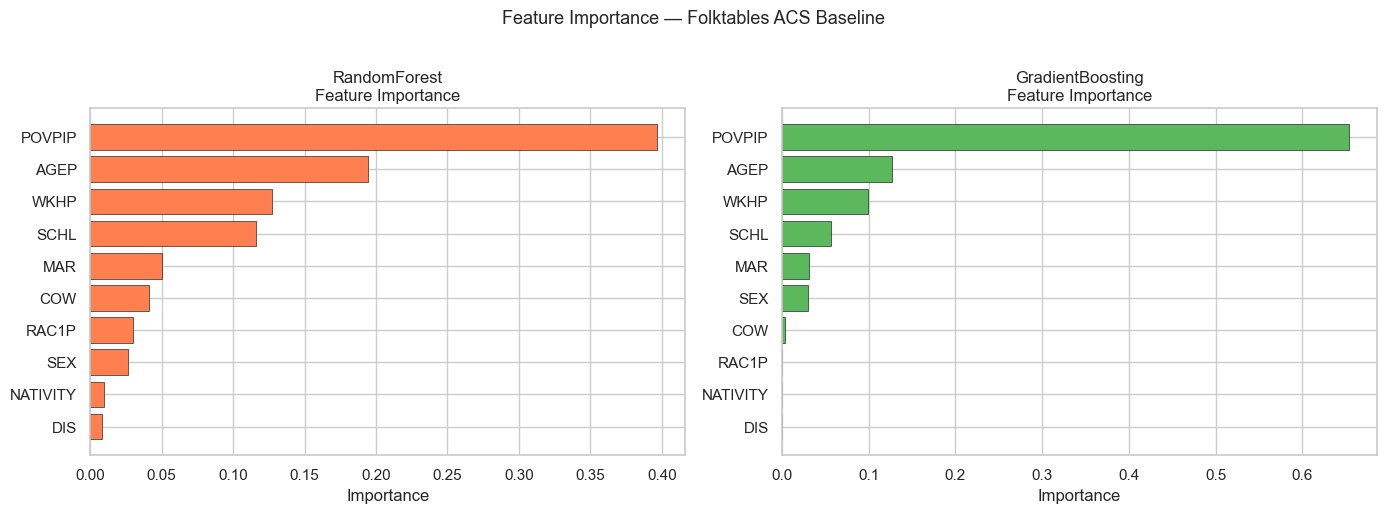

POVPIP (poverty ratio) and WKHP (hours worked) expected to dominate


In [8]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(14,5))
for ax, name in zip([ax1,ax2],['RandomForest','GradientBoosting']):
    imp = results[name]['model'].feature_importances_
    idx = np.argsort(imp)
    ax.barh([feature_cols[i] for i in idx], imp[idx],
            color=MODEL_COLORS[name], edgecolor='black', linewidth=0.4)
    ax.set_title(f'{name}\nFeature Importance', fontsize=12)
    ax.set_xlabel('Importance')
plt.suptitle('Feature Importance — Folktables ACS Baseline', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/folktables_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('POVPIP (poverty ratio) and WKHP (hours worked) expected to dominate')

## 7. Confusion Matrices

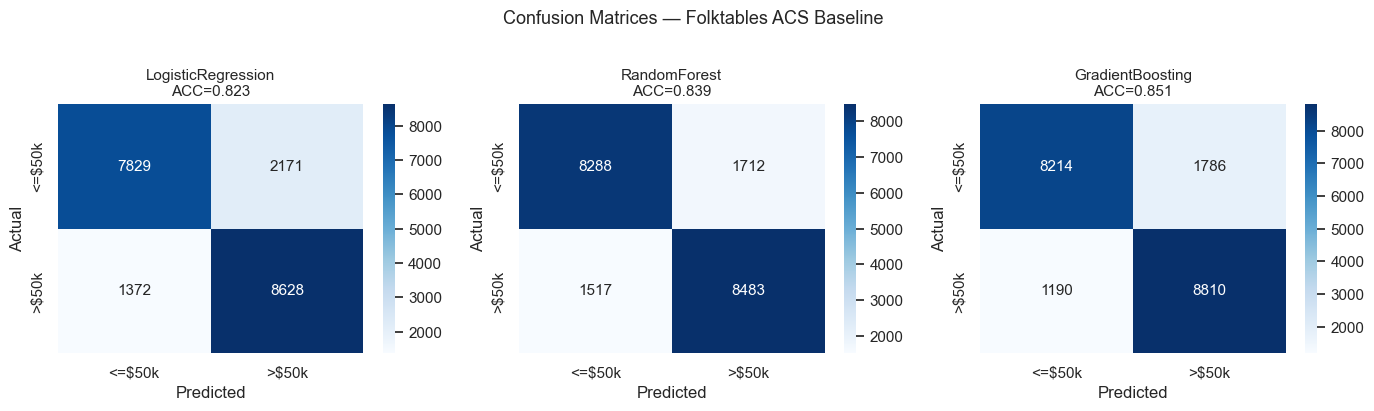

In [9]:
fig, axes = plt.subplots(1,3, figsize=(14,4))
for ax,(name,res) in zip(axes,results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['<=$50k','>$50k'], yticklabels=['<=$50k','>$50k'])
    ax.set_title(f'{name}\nACC={res["acc"]:.3f}', fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — Folktables ACS Baseline', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/baseline/folktables_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Disparate Impact Ratio by Race

DIR = positive rate (group) / positive rate (White reference). DIR < 0.8 is legally actionable under EEOC disparate impact doctrine. Black, Am.Indian, Other, and Two or more all below threshold.

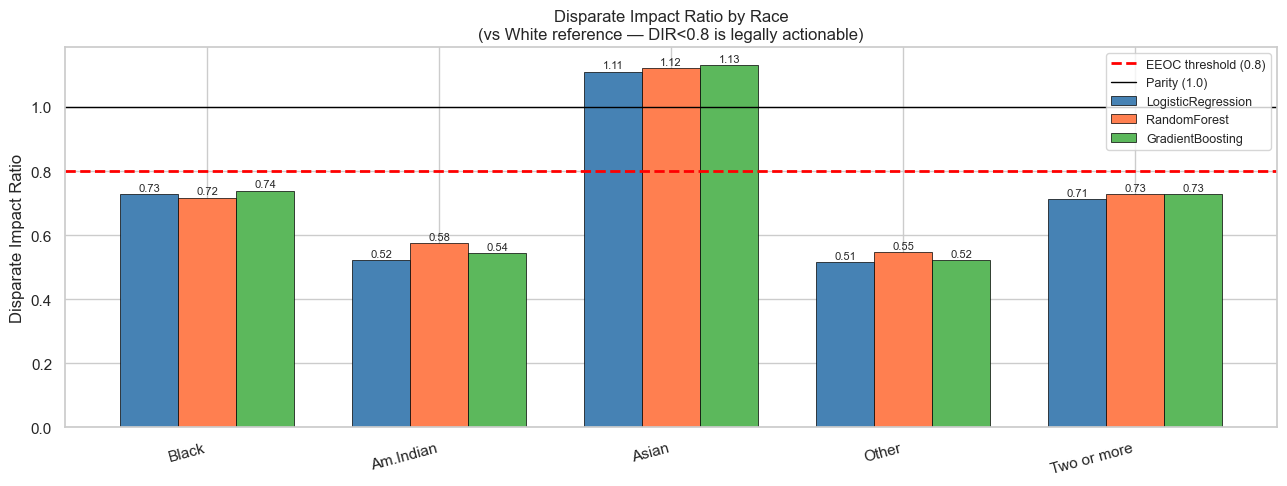

Black DIR=0.73, Am.Indian DIR=0.52, Other DIR=0.51 — all below EEOC 0.8 threshold


In [10]:
dir_races = [2,3,6,8,9]
dir_names = [RAC1P_LABELS[r] for r in dir_races]
dir_data = {}
for name, res in results.items():
    white_rate = res['y_pred'][race_test==1].mean()
    dirs = []
    for race in dir_races:
        mask = race_test==race
        if mask.sum() < 50:
            dirs.append(0); continue
        dirs.append(res['y_pred'][mask].mean() / white_rate)
    dir_data[name] = dirs

x = np.arange(len(dir_races)); width = 0.25
fig, ax = plt.subplots(figsize=(13,5))
for i,(name,dirs) in enumerate(dir_data.items()):
    ax.bar(x+i*width, dirs, width, label=name,
           color=MODEL_COLORS[name], edgecolor='black', linewidth=0.5)
ax.axhline(y=0.8, color='red', linestyle='--', linewidth=2, label='EEOC threshold (0.8)')
ax.axhline(y=1.0, color='black', linestyle='-', linewidth=1, label='Parity (1.0)')
ax.set_xticks(x+width); ax.set_xticklabels(dir_names, rotation=15, ha='right')
ax.set_title('Disparate Impact Ratio by Race\n(vs White reference — DIR<0.8 is legally actionable)', fontsize=12)
ax.set_ylabel('Disparate Impact Ratio'); ax.legend(fontsize=9)
for i,(name,dirs) in enumerate(dir_data.items()):
    for j,val in enumerate(dirs):
        if val > 0:
            ax.text(j+i*width, val+0.01, f'{val:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/baseline/folktables_disparate_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print('Black DIR=0.73, Am.Indian DIR=0.52, Other DIR=0.51 — all below EEOC 0.8 threshold')

## 9. Key Findings

**Best model:** GradientBoosting (AUC=0.929) — much stronger than COMPAS (0.751). Income is more predictable than recidivism.

**Race disparity — EEOC violations:** Black DIR=0.73, Am.Indian DIR=0.52, Other DIR=0.51, Two or more DIR=0.71 — all below the 0.8 EEOC threshold. Asian DIR=1.13 — above White, no EEOC concern.

**Sex gap:** Male positive rate 57.0% vs Female 42.1% — 14.9% gap consistent across all models. Female TPR lower than Male — women with high incomes are systematically under-predicted.

**Note on sampling:** Training balanced to 50/50. Population income rate is 42.8%. Stage 2 ThresholdOptimizer will use population-calibrated thresholds.

**Stage 2 target:** Bring Black, Am.Indian, Other DIR above 0.8 threshold while maintaining AUC > 0.90.